# Treinar CNN para classificar o conjunto de dados Cifar-10 (Imagens)
> Adaptado da seção [*Image Classification Fundamentals*](https://mjrovai.github.io/EdgeML_Made_Ease_ebook/raspi/image_classification/image_classification_fund.html) do [Prof. Marcelo Rovai](https://github.com/Mjrovai) no livro [*EdgeML Made Easy*](https://mjrovai.github.io/EdgeML_Made_Ease_ebook/) e do repositório do GitHub [Edge Machine Learning Systems Engineering](https://github.com/Mjrovai/UNIFEI-IESTI05-EDGE_AI/tree/main).


<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/fabiobento/sis-emb-2025-2/blob/main/aulas/sbc-rpi/rpi_img_class_tflite/docs/4_CNN_Cifar_10_TFLite.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/fabiobento/sis-emb-2025-2/blob/main/aulas/sbc-rpi/rpi_img_class_tflite/docs/4_CNN_Cifar_10_TFLite.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

Nesse notebook vamos fazer classificação das classes do [CIFAR](https://www.cs.toronto.edu/~kriz/cifar.html) (“avião”, “automóvel”, “pássaro”, “gato”, “cervo”, “cão”, “sapo”, “cavalo”, “navio” e “caminhão”). 
- O CIFAR é composto por imagens coloridas de 32x32 (3 canais de cor).
- As imagens do CIFAR não são centralizadas e podem ter o objeto com um fundo, como aviões que podem ter um céu nublado atrás deles!

## Importar bibliotecas necessárias

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten
from tensorflow.keras.callbacks import EarlyStopping

2025-10-27 15:48:15.174387: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-27 15:48:15.182831: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1761590895.193593  151782 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1761590895.196803  151782 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1761590895.204931  151782 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

## Importar e inspecionar o conjunto de dados CIFAR-10

A página do conjunto de dados Cifar-10 é: https://www.cs.toronto.edu/~kriz/cifar.html

In [4]:
# Importa o módulo do dataset CIFAR-10 de dentro da biblioteca Keras,
# que faz parte do TensorFlow. A variável 'cifar10' agora serve como um atalho
# para acessar as funções relacionadas a este dataset.
cifar10 = tf.keras.datasets.cifar10

# Chama a função load_data() para baixar (se necessário) e carregar o dataset CIFAR-10.
# A função retorna os dados já divididos em dois conjuntos: um para treino e outro para teste.
# Esses dados são desempacotados em quatro variáveis:
#   - train_images: Imagens usadas para treinar o modelo.
#   - train_labels: Rótulos (respostas corretas) correspondentes às imagens de treino.
#   - test_images: Imagens usadas para avaliar o desempenho do modelo após o treino.
#   - test_labels: Rótulos correspondentes às imagens de teste.
(train_images, train_labels), (test_images, test_labels) = cifar10.load_data()

In [6]:
# Imprime as dimensões (formato) dos dados de treino.
# train_images.shape: Mostra (quantidade de imagens, altura, largura, canais de cor).
# train_labels.shape: Mostra (quantidade de rótulos, 1).
print(train_images.shape, train_labels.shape)

# Imprime as dimensões (formato) dos dados de teste.
# A lógica é a mesma dos dados de treino.
print(test_images.shape, test_labels.shape)

(50000, 32, 32, 3) (50000, 1)
(10000, 32, 32, 3) (10000, 1)



- O formato dos dados da imagem é: `(#imagens, altura_da_imagem, largura_da_imagem, #canais)`, onde os canais estão no formato RGB (vermelho, verde, azul).
- O formato dos rótulos é `(#imagens, rótulo)`, onde o rótulo varia de 0 a 9.
11


In [ ]:
# Acessa e exibe o conteúdo da primeira imagem do conjunto de dados de treino.
# Em programação, a contagem de elementos (indexação) começa em 0,
# então '[0]' se refere ao primeiro item.
# A saída será um array NumPy tridimensional representando os pixels
# da imagem (altura, largura, canais de cor RGB).
train_images[1]

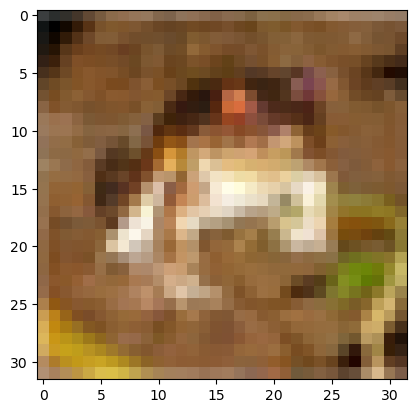

In [ ]:
# Utiliza a função 'imshow' da biblioteca Matplotlib (com o apelido 'plt')
# para exibir uma imagem específica do conjunto de dados de treino.
# O [1] seleciona a segunda imagem da coleção (pois a contagem em programação começa em 0).
# O ponto e vírgula (;) no final é opcional e serve para ocultar a saída de texto
# da função no notebook, mostrando apenas a imagem.
plt.imshow(train_images[1]);

In [ ]:
# Acessa o rótulo (a resposta correta) da segunda imagem do conjunto de treino.
# O primeiro índice [1] seleciona o segundo elemento da lista de rótulos.
# O segundo índice [0] é usado para extrair o valor numérico de dentro do
# array retornado (ex: para obter o número 9 do array [9]).
train_labels[1][0]

np.uint8(6)

Os rótulos CIFAR são matrizes, e é por isso que você precisa de mais um índice para acessar o valor real do rótulo.    

In [16]:
# Cria uma lista com os nomes das 10 classes de objetos do dataset CIFAR-10.
# A ordem dos nomes na lista corresponde aos rótulos numéricos do dataset
# (ex: a classe 0 é 'airplane', a classe 1 é 'automobile', e assim por diante),
# permitindo a tradução dos resultados do modelo para algo legível.
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [22]:
# Acessa o elemento na décima posição da lista 'class_names' (índice 9).
# Como a ordem da lista corresponde aos rótulos numéricos, este comando
# "traduz" o rótulo número 9 para o seu nome correspondente, que é 'truck'.
class_names[9]

'truck'

In [ ]:
# 'train_labels[1]' acessa o segundo rótulo, e '[0]' extrai o valor
# numérico de dentro do array (por exemplo, o número 9).
# A variável 'idx' agora armazena esse número.
idx = train_labels[1][0]

#Usa o rótulo numérico ('idx') como índice para encontrar o nome
# da classe correspondente na lista 'class_names'.
# Isso efetivamente "traduz" o número da classe para um nome legível.
class_names[idx]

'truck'

		 truck


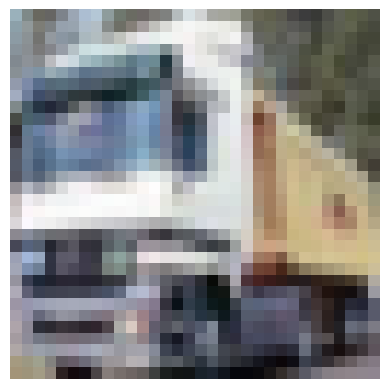

In [27]:
print("\t\t", class_names[train_labels[1][0]])
plt.imshow(train_images[1])
plt.axis('off');

In [ ]:
# Função para exibir uma imagem de treino.
# A função recebe o índice da imagem ('img') e um tamanho opcional para a figura ('size').
def plot_train_img(img, size=2):
    # Obtém o rótulo numérico da imagem especificada, extraindo o valor do array.
    label = train_labels[img][0]
    
    # Cria uma nova figura para o gráfico com o tamanho definido (padrão 2x2 polegadas).
    plt.figure(figsize=(size,size))
    
    # Imprime o rótulo numérico e o nome da classe correspondente.
    print("Rótulo {} - {}".format(label, class_names[label]))
    
    # Exibe a imagem do conjunto de treino na figura.
    plt.imshow(train_images[img])
    
    # Oculta os eixos x e y do gráfico para uma visualização mais limpa da imagem.
    plt.axis('off')
    
    # Mostra a figura final na tela.
    plt.show()

Rótulo 9 - truck


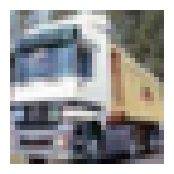

In [29]:
plot_train_img(1)

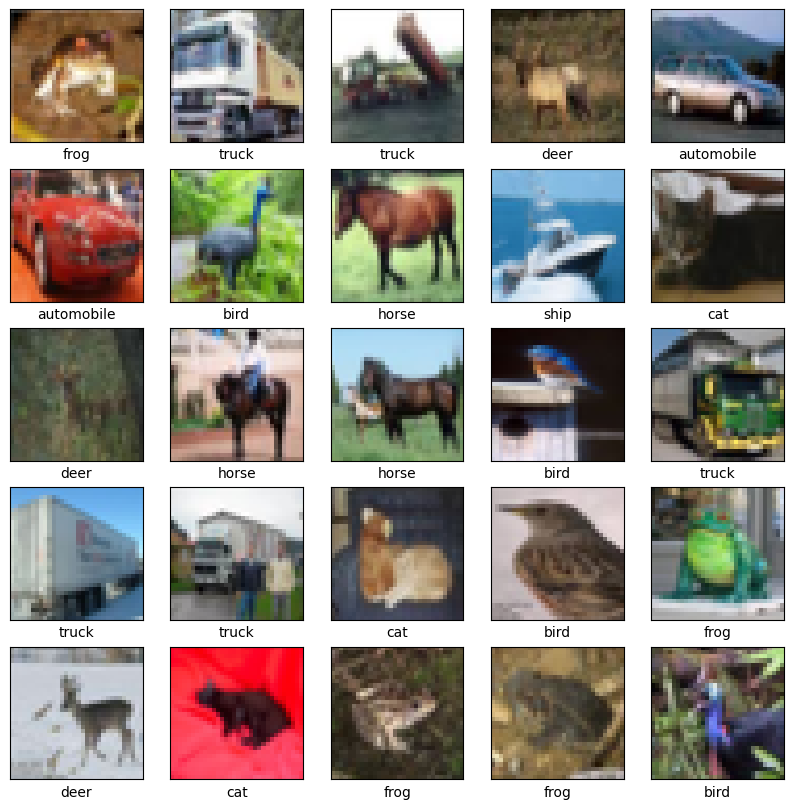

In [ ]:
# Cria uma nova figura para a plotagem com um tamanho total de 10x10 polegadas.
plt.figure(figsize=(10,10))

# Inicia um laço de repetição para exibir as primeiras 25 imagens (índices de 0 a 24).
for i in range(25):
    # Define uma grade de 5x5 subplots e seleciona a posição 'i+1' para a imagem atual.
    plt.subplot(5,5,i+1)
    
    # Remove as marcações numéricas do eixo x para uma visualização mais limpa.
    plt.xticks([])
    
    # Remove as marcações numéricas do eixo y.
    plt.yticks([])
    
    # Desativa as linhas de grade no fundo da imagem.
    plt.grid(False)
    
    # Exibe a i-ésima imagem do conjunto de treino no subplot atual.
    plt.imshow(train_images[i])
    
    # Define o texto abaixo da imagem como o nome da classe correspondente.
    # Para isso, ele pega o rótulo numérico (ex: 9) e usa como índice para
    # encontrar o nome na lista 'class_names' (ex: 'truck').
    plt.xlabel(class_names[train_labels[i][0]])

# Exibe a figura completa com todas as 25 imagens e seus rótulos.
plt.show()

Observe que as imagens são coloridas, não estão centralizadas e têm fundos diferentes.

## Preprocessando o conjunto de dados

In [ ]:
test_images.max()

In [ ]:
# Normalize os valores dos pixels para que fiquem entre 0 e 1.
train_images = train_images / 255.0
test_images = test_images / 255.0

In [ ]:
test_images.max()

In [ ]:
plt.hist(train_labels[:5_000]);

In [ ]:
val_images = train_images[:5_000]
val_labels = train_labels[:5_000]
print(val_images.shape, val_labels.shape)

In [ ]:
train_images = train_images[5_000:]
train_labels = train_labels[5_000:]
print(train_images.shape, train_labels.shape)

In [ ]:
plt.hist(train_labels, alpha=0.5)
plt.hist(val_labels, alpha=0.5)
plt.hist(test_labels, alpha=0.5);

## Criar arquitetura do modelo e compilar

Em [Camadas de convolução](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Conv2D),
- strides é um número inteiro ou uma tupla/lista de 2 números inteiros, especificando os passos da convolução ao longo da altura e largura. Padrão (1,1).
- padding: um dos valores “valid” ou “same” (sem distinção entre maiúsculas e minúsculas). Padrão = ‘valid’.
- “valid” significa sem preenchimento.
- “same” resulta em preenchimento com zeros uniformemente
à esquerda/direita ou acima/abaixo da entrada, de modo que a saída tenha o mesmo

In [ ]:
model = Sequential()


model.add(Conv2D(
    filters=32,
    kernel_size=(3,3),
    activation='relu',
    input_shape=(32, 32, 3))
)
model.add(MaxPool2D(2, 2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPool2D())

model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))

model.summary()

In [ ]:
LOSS = 'sparse_categorical_crossentropy'
OPTIMIZER = 'adam'

# Compilando o modelo
model.compile(optimizer=OPTIMIZER,
              loss=LOSS,
              metrics=['accuracy'])

## Treinando o modelo

In [ ]:
NUM_EPOCHS = 20

early_stop = EarlyStopping(monitor='val_loss',patience=3)

In [ ]:
# treinando o modelo
history = model.fit(train_images,
                    train_labels,
                    epochs=NUM_EPOCHS,
                    validation_data=(val_images, val_labels),
                    callbacks=[early_stop]
)

In [ ]:
# sumarizando o histórico para acurácia
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('acurácia do modelo')
plt.ylabel('acurácia')
plt.xlabel('época')
plt.legend(['train', 'validation'], loc='upper left')
#plt.xlim([0,NUM_EPOCHS])
plt.ylim([0.4,1.0])
plt.show()

## Avaliar o modelo

In [ ]:
model.evaluate(test_images, test_labels)

**Acurácia**
- Treino: 85% - 90%;
- Validação: 68%-70%
- Teste: 66%-68%

In [ ]:
predictions = np.argmax(model.predict(test_images), axis=-1)
predictions.shape

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix

In [ ]:
print(classification_report(test_labels, predictions, target_names=class_names))

In [ ]:
confusion_matrix(test_labels,predictions)

In [ ]:
class_names

In [ ]:
import seaborn as sns
plt.figure(figsize=(15,8))
sns.heatmap(confusion_matrix(test_labels,predictions), cmap='Blues', annot=True, fmt='g');

## Testando o modelo (previsão de algumas imagens de teste)

In [ ]:
plt.imshow(test_images[15]);

In [ ]:
test_labels[15][0]

In [ ]:
class_names[8]

In [ ]:
test_images[15].shape

A forma do tensor de entrada deve ser: (num_images, largura, altura, canais_de_cor)


In [ ]:
my_image = test_images[15]
my_image = my_image.reshape(1,32,32,3)
my_image.shape

In [ ]:
img_pred = np.argmax(model.predict(my_image))
class_names[img_pred]

In [ ]:
img_pred

In [ ]:
pred_prob = model.predict(my_image)[0][img_pred]
pred_prob

In [ ]:
def img_pred(img, size=4):
    label = test_labels[img][0]
    my_image = test_images[img]
    plt.figure(figsize=(size,size))
    plt.imshow(my_image)
    my_image = my_image.reshape(1,32,32,3)
    img_pred = np.argmax(model.predict(my_image))
    pred_label = class_names[img_pred]
    pred_prob = model.predict(my_image)[0][img_pred]
    print(" Label {} <=> Pred: {} with prob {:.2}".format(
        class_names[label],
        pred_label,
        pred_prob))
    plt.grid(False)
    plt.axis('off')
    plt.show()

In [ ]:
img_pred(0)

In [ ]:
for i in range (10):
  img_pred(i)

## Salvando o modelo treinado

In [ ]:
!pwd  # Comando Linux, mostra onde estamos nas pastas do CoLab

In [ ]:
model.save('cifar_10_model.h5')

- Use o [Netron](https://netron.app) para visualizar o modelo, hiperparâmetros, formas de sensores, etc.
- O Netron é um visualizador para modelos de redes neurais, aprendizado profundo e aprendizado de máquina (consulte o [GitHub](https://github.com/lutzroeder/netron) para obter instruções sobre a instalação em seu desktop).

# Convertendo o modelo para TFLite

You can convert the TF trained model using:  `TFLiteConverter.from_keras_model(model)`

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)

Alternativamente, é possível converter o modeloa partir:
- de um modelo salvo.: `tf.lite.TFLiteConverter.from_saved_model(model_cifar10)` ou
- de um modelo Keras: `tf.lite.TFLiteConverter.from_keras_model(model_cifar10.h5)`

In [ ]:
# model_path = '/content/cifar_10_model'
# model_cifar10 = tf.keras.models.load_model(model_path)
# converter = tf.lite.TFLiteConverter.from_saved_model(model_cifar10)
# converter = tf.lite.TFLiteConverter.from_keras_model(model_cifar10)

In [ ]:
tflite_model = converter.convert()

In [ ]:
# Salvar o modelo .tflite
open("/content/cifar10.tflite","wb").write(tflite_model)

## Quantização da faixa dinâmica (*Dynamic range quantization*)
A forma mais simples de quantização pós-treinamento quantiza estaticamente apenas os pesos de ponto flutuante para inteiro, que tem 8 bits de precisão:

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quant_model = converter.convert()


In [ ]:
# Salvar o modelo .tflite
open("/content/cifar10_quant.tflite","wb").write(tflite_quant_model)

Use o [Netron](https://netron.app) para visualizar o modelo quantizado. Preste atenção que agora os pesos são int8.

## Carregando um modelo TF salvo para conversão

Se você deseja carregar seu modelo salvo anteriormente para evitar retreiná-lo:

1.   À esquerda da interface do usuário, clique no ícone da pasta e vá para a subpasta “content”.
2.   Clique nos três pontos à direita do arquivo da pasta “content” e selecione upload”.



In [ ]:
model_path = '/content/cifar_10_model.h5'
model_cifar10 = tf.keras.models.load_model(model_path)
converter = tf.lite.TFLiteConverter.from_keras_model(model_cifar10)

In [ ]:
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quant_model = converter.convert()

In [ ]:
# Salvar o modelo .tflite
tflite_model_size = open("/content/cifar10_quant_model.tflite","wb").write(tflite_quant_model)
print("Quantized model (DEFAULT) is {:,} bytes".format(tflite_model_size))

## Testando o modelo TFLite

In [ ]:
interpreter = tf.lite.Interpreter("/content/cifar10_quant_model.tflite")

In [ ]:
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

In [ ]:
input_details

In [ ]:
output_details

In [ ]:
def set_input_tensor(interpreter, image):
    tensor_index = interpreter.get_input_details()[0]['index']
    input_tensor = interpreter.tensor(tensor_index)()[0]
    input_tensor[:, :] = image

In [ ]:
image = test_images[0]
plt.imshow(image);

In [ ]:
set_input_tensor(interpreter, image)
interpreter.invoke()
output_details = interpreter.get_output_details()[0]

In [ ]:
interpreter.get_tensor(output_details['index'])

In [ ]:
np.squeeze(interpreter.get_tensor(output_details['index']))

In [ ]:
output = np.squeeze(interpreter.get_tensor(output_details['index']))
output

In [ ]:
img_pred = np.argmax(output)
class_names[img_pred]

In [ ]:
img_pred

In [ ]:
output[img_pred]

In [ ]:
def classify_image(image):
    set_input_tensor(interpreter, image)
    interpreter.invoke()
    output_details = interpreter.get_output_details()[0]
    output = np.squeeze(interpreter.get_tensor(output_details['index']))
    img_pred = np.argmax(output)
    pred_label = class_names[img_pred]
    pred_prob = output[img_pred]
    plt.imshow(image)
    print(" Pred: {} with prob {:.2}".format(
        pred_label,
        pred_prob))
    plt.grid(False)
    plt.axis('off')
    plt.show()

In [ ]:
classify_image(test_images[0])

In [ ]:
for i in range (10):
  classify_image(test_images[i])

# TensorFlow Lite Micro

In [ ]:
import tensorflow as tf

In [ ]:
model_path = '/content/cifar_10_model.h5'
model_cifar10 = tf.keras.models.load_model(model_path)
converter = tf.lite.TFLiteConverter.from_keras_model(model_cifar10)

In [ ]:
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quant_model = converter.convert()

In [ ]:
# Salvar o modelo .tflite
tflite_model_size = open("/content/cifar10_quant_model.tflite","wb").write(tflite_quant_model)
print("Quantized model (DEFAULT) is {:,} bytes".format(tflite_model_size))

### Gere um modelo TensorFlow Lite para microcontroladores
Para converter o modelo quantizado TensorFlow Lite em um arquivo fonte C que possa ser carregado pelo TensorFlow Lite para microcontroladores em MCUs, basta usar a ferramenta xxd para converter o arquivo .tflite em um arquivo .cc.

**Converter para um array C**

Primeiro instale o xxd

In [ ]:
!apt-get update && apt-get -qq install xxd

Agora, converta e salve o modelo convertido em .cc.

In [ ]:
MODEL_TFLITE = 'cifar10_quant_model.tflite'
MODEL_TFLITE_MICRO = 'cifar10_quant_model.cc'
!xxd -i {MODEL_TFLITE} > {MODEL_TFLITE_MICRO}
REPLACE_TEXT = MODEL_TFLITE.replace('/', '_').replace('.', '_')
!sed -i 's/'{REPLACE_TEXT}'/g_model/g' {MODEL_TFLITE_MICRO}

Se você deseja baixar seu modelo para mantê-lo em segurança:
1. À esquerda da interface do usuário, clique no ícone da pasta
2. Clique nos três pontos à direita do arquivo ```cifar10_quant_model.cc``` e selecione baixar

In [ ]:
!cat {MODEL_TFLITE_MICRO}